# Disaster Tweets — data understanding

Kaggle: https://www.kaggle.com/competitions/nlp-getting-started — label each tweet as about a real disaster (1) or
not (0); scored by F1 on the positive class.

Before any model: how noisy are the labels, which metadata carries signal, which words separate the classes, whether
the test set looks like the training set, and what structure TF-IDF space has. Every figure is saved to `assets/`.

In [1]:
import re, json, os
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats, sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PAL = ["#4C72B0", "#C44E52"]  # 0 = not a disaster, 1 = disaster
os.makedirs("assets", exist_ok=True); os.makedirs("results", exist_ok=True)
train = pd.read_csv("data/train.csv"); test = pd.read_csv("data/test.csv")
y = train.target.values
print(train.shape, test.shape, "positive rate", round(y.mean(), 4))

(7613, 5) (3263, 4) positive rate 0.4297


## 1. Shape of the data: balance and missingness

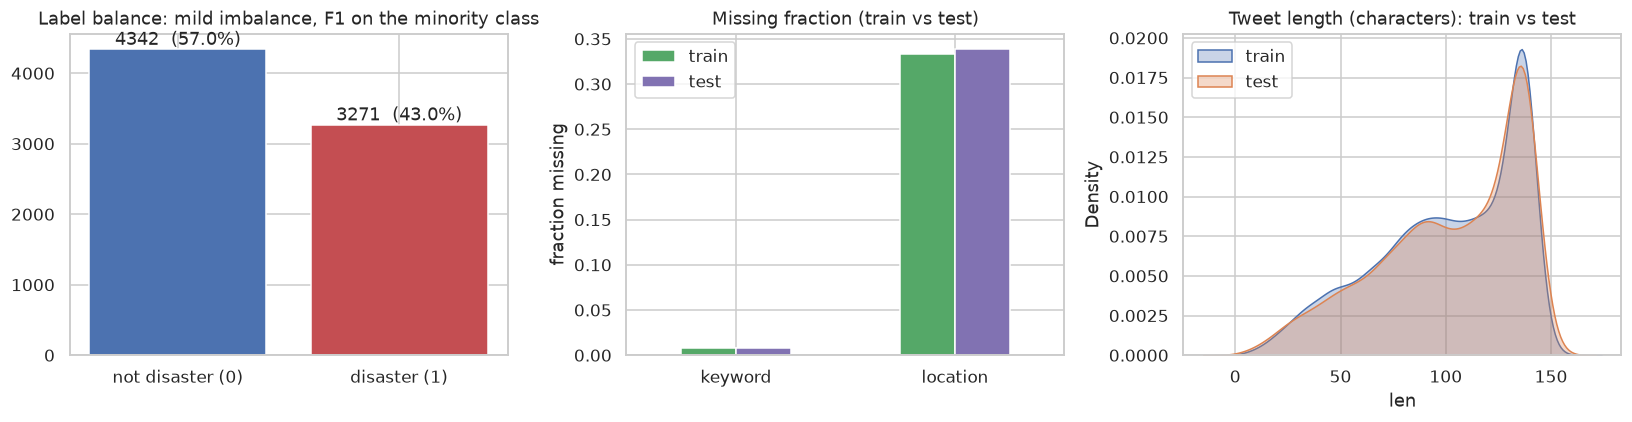

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cnt = train.target.value_counts().sort_index()
axes[0].bar(["not disaster (0)", "disaster (1)"], cnt.values, color=PAL)
for i, v in enumerate(cnt.values): axes[0].text(i, v + 60, f"{v}  ({v/len(train):.1%})", ha="center")
axes[0].set_title("Label balance: mild imbalance, F1 on the minority class")
miss = pd.DataFrame({"train": train[["keyword", "location"]].isna().mean(), "test": test[["keyword", "location"]].isna().mean()})
miss.plot.bar(ax=axes[1], rot=0, color=["#55A868", "#8172B2"]); axes[1].set_title("Missing fraction (train vs test)"); axes[1].set_ylabel("fraction missing")
train["len"] = train.text.str.len(); test["len"] = test.text.str.len()
sns.kdeplot(train.len, ax=axes[2], label="train", fill=True, alpha=.3); sns.kdeplot(test.len, ax=axes[2], label="test", fill=True, alpha=.3)
axes[2].set_title("Tweet length (characters): train vs test"); axes[2].legend()
plt.tight_layout(); plt.savefig("assets/eda_01_balance_missingness.png", bbox_inches="tight"); plt.show()

## 2. Label noise: duplicated tweets with conflicting labels

A tweet that appears several times with different labels cannot be classified correctly in every copy. These conflicts
bound the achievable accuracy and estimate how often annotators disagree.

duplicated texts: 69 (179 rows); with conflicting labels: 18 (55 rows)
errors unavoidable on training rows: 22 of 7613 (0.29%)


,text,size,mean
0,The Prophet (peace be upon him) said 'Save yourself from Hellfire even if it is by giving half,6,0.333333
1,He came to a land which was engulfed in tribal war and turned it into a land of peace i.e. Madi,6,0.333333
2,that horrible sinking feeling when youÛªve been at home on your phone for a while and you real,4,0.500000
3,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced peopl,4,0.750000
4,To fight bioterrorism sir.,4,0.500000
5,#Allah describes piling up #wealth thinking it would last #forever as the description of the pe,3,0.333333


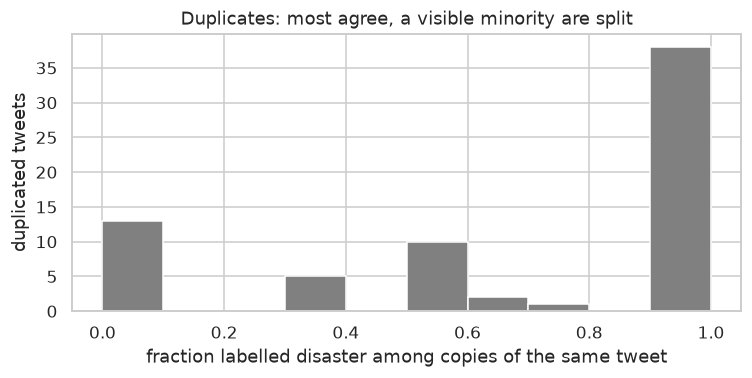

In [3]:
g = train.groupby("text").target.agg(["nunique", "size", "mean"])
dup = g[g["size"] > 1]; conf = g[g["nunique"] > 1]
unavoidable = int((conf["size"] * np.minimum(conf["mean"], 1 - conf["mean"])).round().sum())
print(f"duplicated texts: {len(dup)} ({int(dup['size'].sum())} rows); with conflicting labels: {len(conf)} ({int(conf['size'].sum())} rows)")
print(f"errors unavoidable on training rows: {unavoidable} of {len(train)} ({unavoidable/len(train):.2%})")
pd.set_option("display.max_colwidth", 100)
display(conf.sort_values("size", ascending=False).head(6).assign(text=lambda d: d.index.str[:95]).reset_index(drop=True)[["text", "size", "mean"]])
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(dup["mean"], bins=np.linspace(0, 1, 11), color="grey", edgecolor="white"); ax.set_xlabel("fraction labelled disaster among copies of the same tweet")
ax.set_ylabel("duplicated tweets"); ax.set_title("Duplicates: most agree, a visible minority are split")
plt.tight_layout(); plt.savefig("assets/eda_02_label_conflicts.png", bbox_inches="tight"); plt.show()
json.dump(dict(conflicting_texts=len(conf), conflicting_rows=int(conf["size"].sum()), unavoidable_errors=unavoidable), open("results/label_noise.json", "w"))

## 3. Keyword: a polarised metadata field

Raw per-keyword positive rates are noisy for rare keywords, so they are shrunk toward the global rate with an
empirical-Bayes beta prior, $\hat p_k = (y_k + a)/(n_k + a + b)$, with $(a, b)$ fitted by the method of moments.

prior Beta(a=0.99, b=1.34); 221 keywords, median 35 tweets each


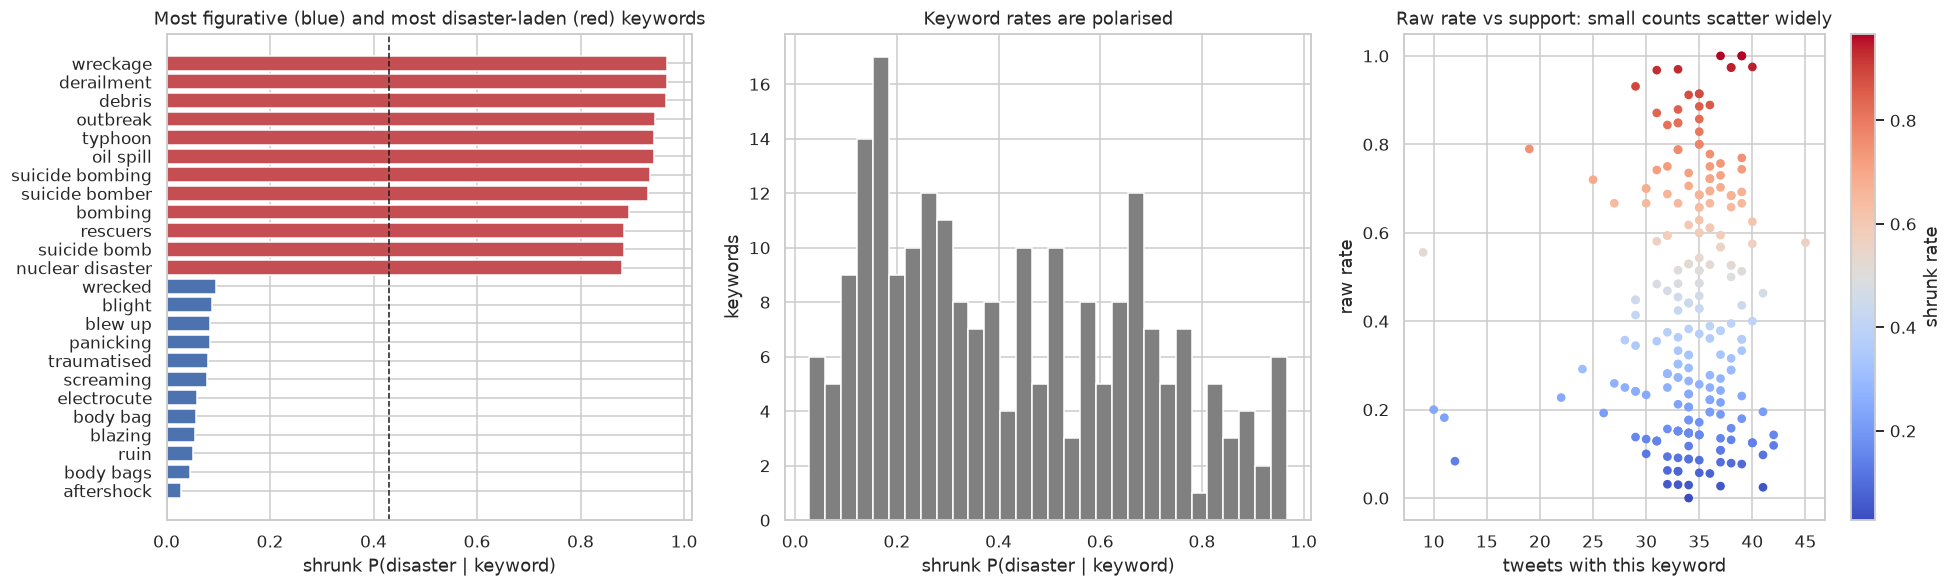

AUC from keyword alone (out-of-fold, shrunk rate): 0.7876


In [4]:
kw = train.dropna(subset=["keyword"]).assign(keyword=lambda d: d.keyword.str.replace("%20", " ")).groupby("keyword").target.agg(["sum", "count"])
r = kw["sum"] / kw["count"]; m, v = r.mean(), r.var(); common = m * (1 - m) / v - 1; a, b = m * common, (1 - m) * common
kw["raw"] = r; kw["shrunk"] = (kw["sum"] + a) / (kw["count"] + a + b)
print(f"prior Beta(a={a:.2f}, b={b:.2f}); {len(kw)} keywords, median {kw['count'].median():.0f} tweets each")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
s = kw.sort_values("shrunk"); top = pd.concat([s.head(12), s.tail(12)])
axes[0].barh(top.index, top["shrunk"], color=[PAL[0]] * 12 + [PAL[1]] * 12); axes[0].axvline(y.mean(), color="k", ls="--", lw=1)
axes[0].set_title("Most figurative (blue) and most disaster-laden (red) keywords"); axes[0].set_xlabel("shrunk P(disaster | keyword)")
axes[1].hist(kw["shrunk"], bins=30, color="grey"); axes[1].set_xlabel("shrunk P(disaster | keyword)"); axes[1].set_ylabel("keywords")
axes[1].set_title("Keyword rates are polarised")
sc = axes[2].scatter(kw["count"], kw["raw"], c=kw["shrunk"], cmap="coolwarm", s=22)
axes[2].set_xlabel("tweets with this keyword"); axes[2].set_ylabel("raw rate"); axes[2].set_title("Raw rate vs support: small counts scatter widely")
plt.colorbar(sc, ax=axes[2], label="shrunk rate")
plt.tight_layout(); plt.savefig("assets/eda_03_keyword_polarisation.png", bbox_inches="tight"); plt.show()
# how much label information does keyword alone carry? out-of-fold AUC of the shrunk rate
oofk = np.zeros(len(train)); kk = train.keyword.fillna("none")
for tr_, va_ in StratifiedKFold(5, shuffle=True, random_state=42).split(train, y):
    st = train.iloc[tr_].groupby(kk.iloc[tr_]).target.agg(["sum", "count"]); sh = (st["sum"] + a) / (st["count"] + a + b)
    oofk[va_] = kk.iloc[va_].map(sh).fillna(y.mean()).values
print(f"AUC from keyword alone (out-of-fold, shrunk rate): {roc_auc_score(y, oofk):.4f}")

## 4. Location: free text, one third missing

target               0     1
location                    
location given    2884  2196
location missing  1458  1075
chi2=0.40, p=0.528


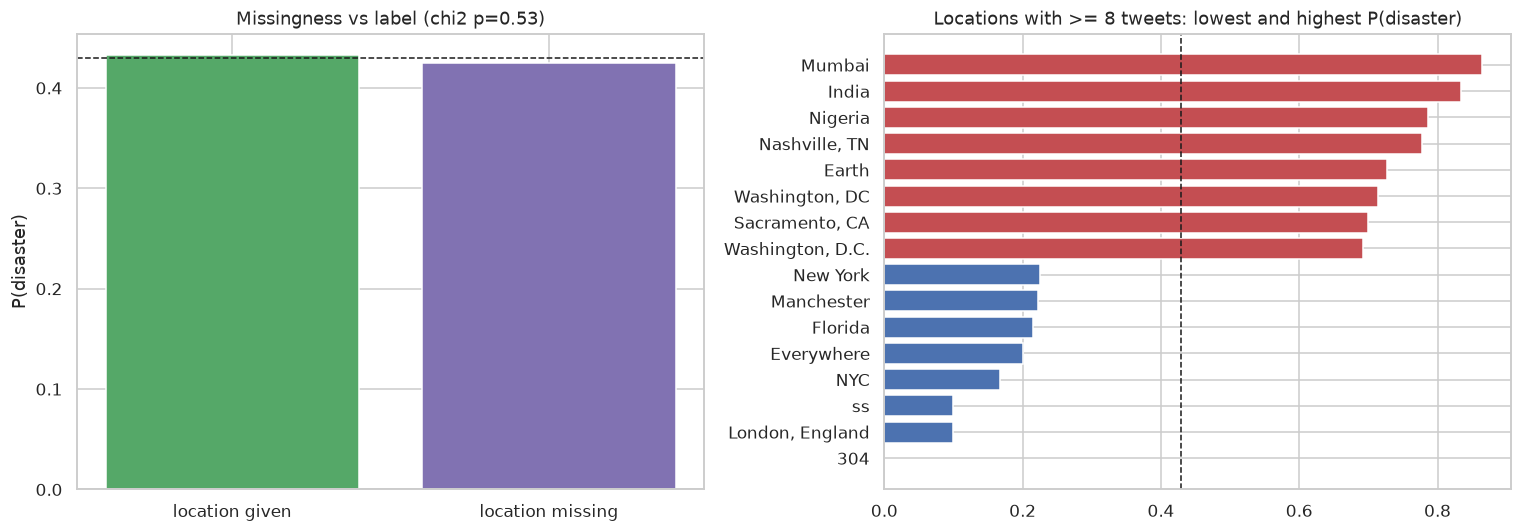

In [5]:
ct = pd.crosstab(train.location.isna(), train.target); chi2, p, *_ = stats.chi2_contingency(ct)
print(ct.rename(index={False: "location given", True: "location missing"})); print(f"chi2={chi2:.2f}, p={p:.3g}")
loc = train.dropna(subset=["location"]).groupby("location").target.agg(["mean", "count"]).query("count >= 8").sort_values("mean")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(["location given", "location missing"], [train.target[train.location.notna()].mean(), train.target[train.location.isna()].mean()], color=["#55A868", "#8172B2"])
axes[0].axhline(y.mean(), color="k", ls="--", lw=1); axes[0].set_ylabel("P(disaster)"); axes[0].set_title(f"Missingness vs label (chi2 p={p:.2g})")
loc_top = pd.concat([loc.head(8), loc.tail(8)]); axes[1].barh(loc_top.index.str[:28], loc_top["mean"], color=[PAL[0]] * 8 + [PAL[1]] * 8)
axes[1].axvline(y.mean(), color="k", ls="--", lw=1); axes[1].set_title("Locations with >= 8 tweets: lowest and highest P(disaster)")
plt.tight_layout(); plt.savefig("assets/eda_04_location.png", bbox_inches="tight"); plt.show()

## 5. Surface features per class

URLs, hashtags, mentions, length and capitalisation differ between news-like disaster reports and casual use of
disaster words. Differences are tested with Mann–Whitney U and reported as the rank-biserial effect size
$r = 1 - 2U/(n_1 n_0)$.

,feature,mean_disaster,mean_other,rank_biserial,p
6,digits,2.6374,1.5905,-0.2573,0.0000
2,urls,0.7698,0.5074,-0.2334,0.0000
0,chars,108.1134,95.7068,-0.1907,0.0000
5,uppercase_ratio,0.1340,0.1284,-0.1395,0.0000
4,mentions,0.2721,0.4203,0.1061,0.0000
8,questions,0.2330,0.5444,0.0857,0.0000
7,exclamations,0.1009,0.1942,0.0605,0.0000
3,hashtags,0.5020,0.3888,-0.0576,0.0000
1,words,15.1675,14.7047,-0.0487,0.0003


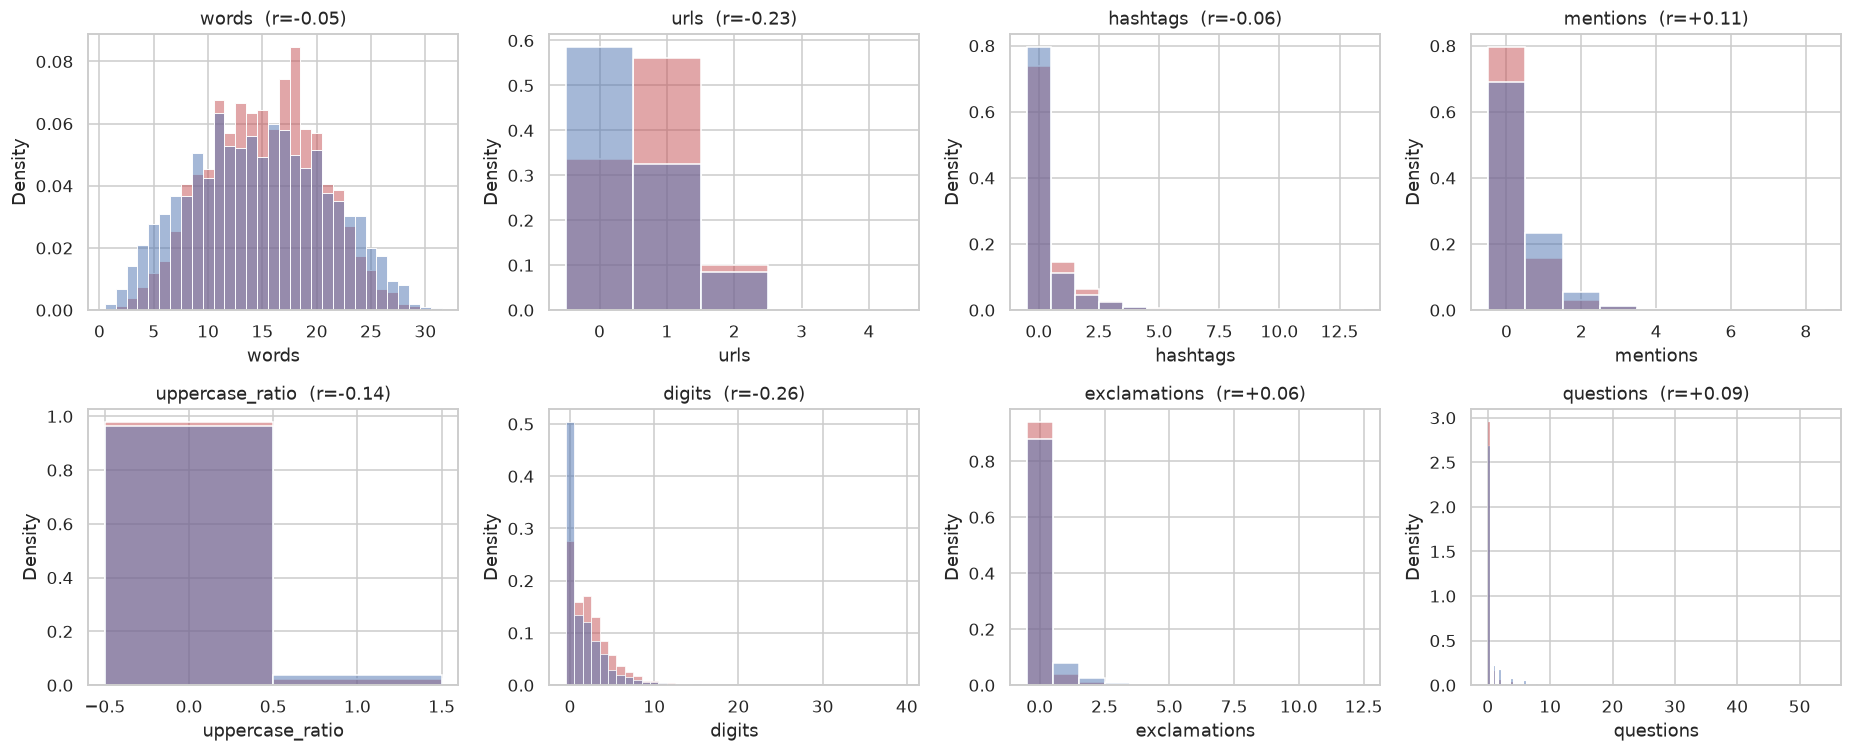

In [6]:
def surface(t):
    return pd.DataFrame({"chars": t.str.len(), "words": t.str.split().str.len(), "urls": t.str.count(r"https?://\S+"),
        "hashtags": t.str.count(r"#\w+"), "mentions": t.str.count(r"@\w+"),
        "uppercase_ratio": t.apply(lambda s: sum(c.isupper() for c in s) / max(1, sum(c.isalpha() for c in s))),
        "digits": t.str.count(r"\d"), "exclamations": t.str.count("!"), "questions": t.str.count(r"\?")})
F = surface(train.text); rows = []
for c in F:
    x1, x0 = F.loc[y == 1, c], F.loc[y == 0, c]; U, p = stats.mannwhitneyu(x1, x0)
    rows.append(dict(feature=c, mean_disaster=x1.mean(), mean_other=x0.mean(), rank_biserial=1 - 2 * U / (len(x1) * len(x0)), p=p))
surf = pd.DataFrame(rows).sort_values("rank_biserial", key=abs, ascending=False); display(surf.round(4))
surf.to_csv("results/surface_feature_tests.csv", index=False)
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, c in zip(axes.ravel(), [c for c in F if c != "chars"][:8]):
    sns.histplot(data=F.assign(target=y), x=c, hue="target", stat="density", common_norm=False, discrete=F[c].max() < 40, ax=ax, palette=PAL, legend=False)
    ax.set_title(f"{c}  (r={surf.set_index('feature').loc[c, 'rank_biserial']:+.2f})")
plt.tight_layout(); plt.savefig("assets/eda_05_surface_features.png", bbox_inches="tight"); plt.show()

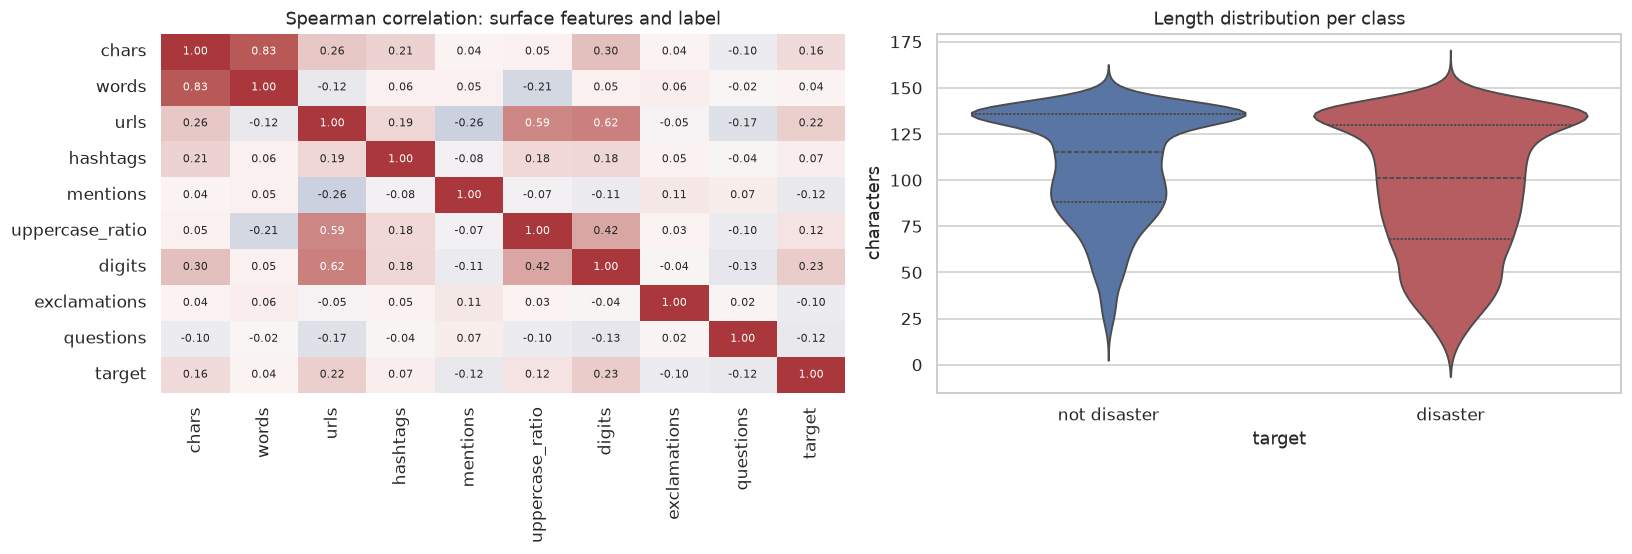

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sns.heatmap(F.assign(target=y).corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0], cbar=False, annot_kws={"size": 7})
axes[0].set_title("Spearman correlation: surface features and label")
sns.violinplot(data=train.assign(target=y.astype(str)), x="target", y="len", hue="target", palette=PAL, ax=axes[1], legend=False, inner="quartile")
axes[1].set_xticks([0, 1], ["not disaster", "disaster"]); axes[1].set_ylabel("characters"); axes[1].set_title("Length distribution per class")
plt.tight_layout(); plt.savefig("assets/eda_06_feature_correlation_length.png", bbox_inches="tight"); plt.show()

## 6. Which words separate the classes: weighted log-odds with an informative Dirichlet prior

Raw frequency differences are dominated by common words and raw log-odds by rare ones. The log-odds ratio with an
informative Dirichlet prior (Monroe, Colaresi & Quinn, 2008) shrinks each word toward its corpus frequency and divides
by its standard error:

$$\delta_w=\log\frac{y_w^{1}+\alpha_w}{n^{1}+\alpha_0-y_w^{1}-\alpha_w}-\log\frac{y_w^{0}+\alpha_w}{n^{0}+\alpha_0-y_w^{0}-\alpha_w},\qquad
z_w=\frac{\delta_w}{\sqrt{1/(y_w^{1}+\alpha_w)+1/(y_w^{0}+\alpha_w)}}$$

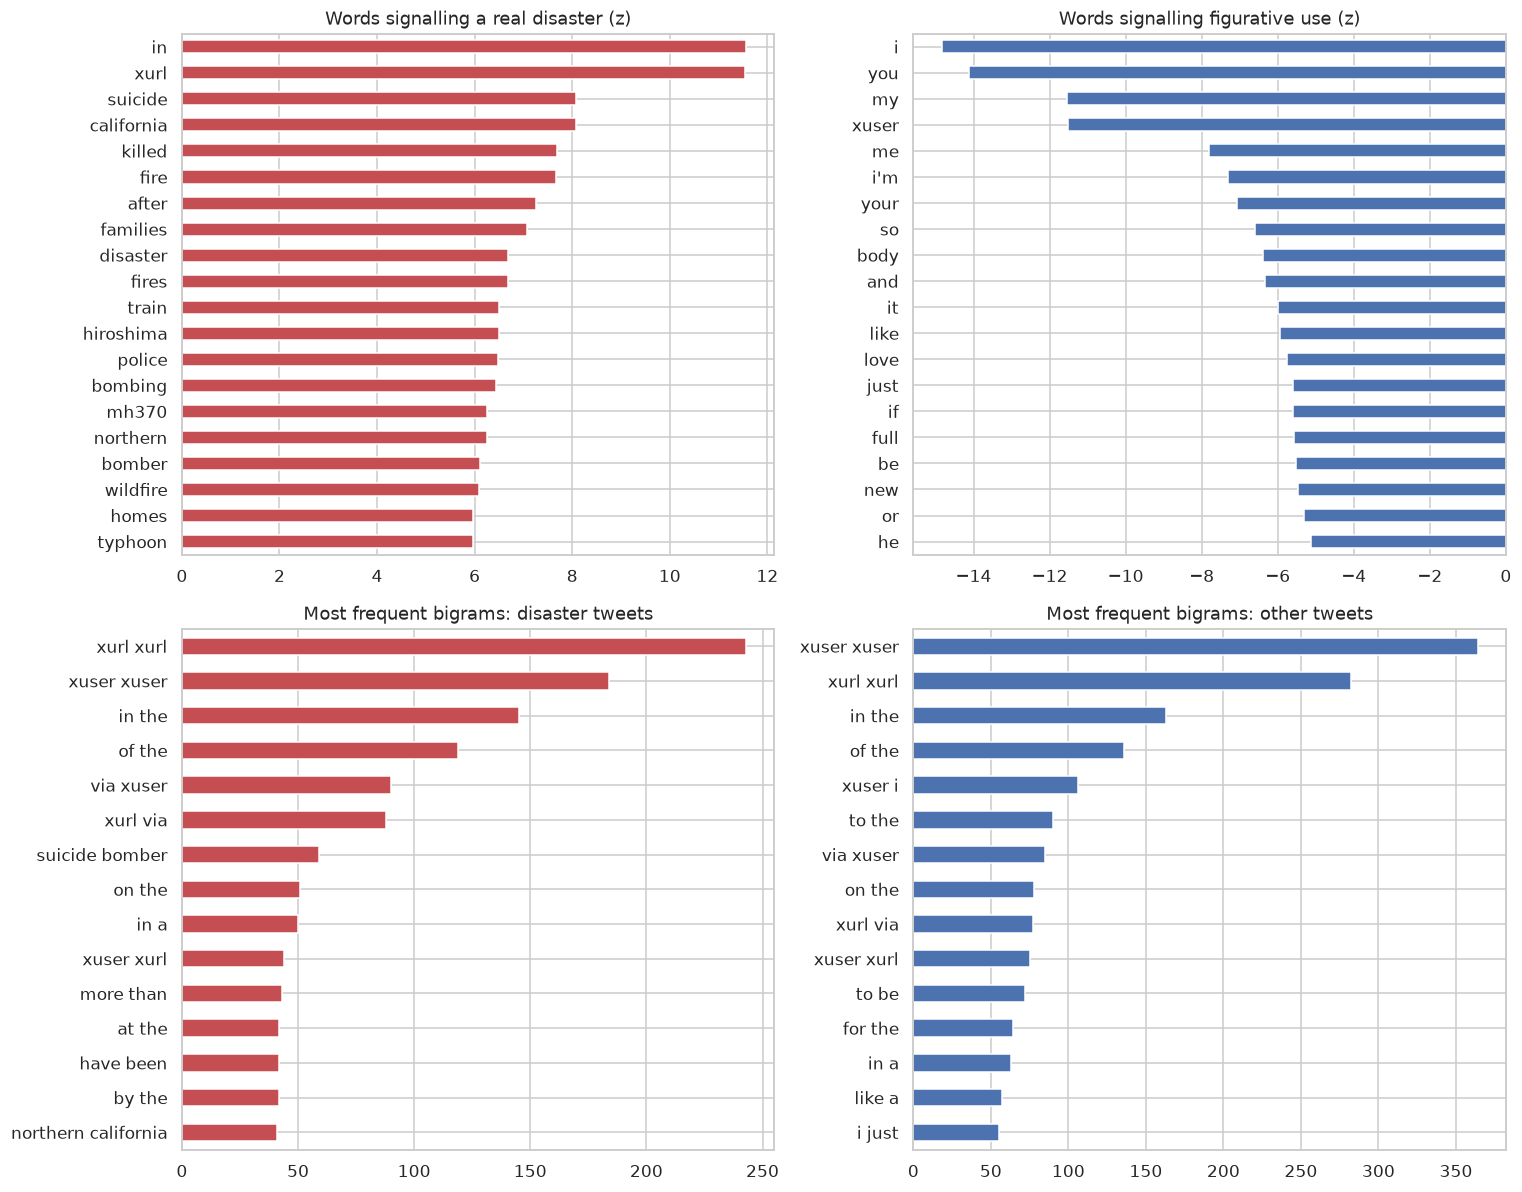

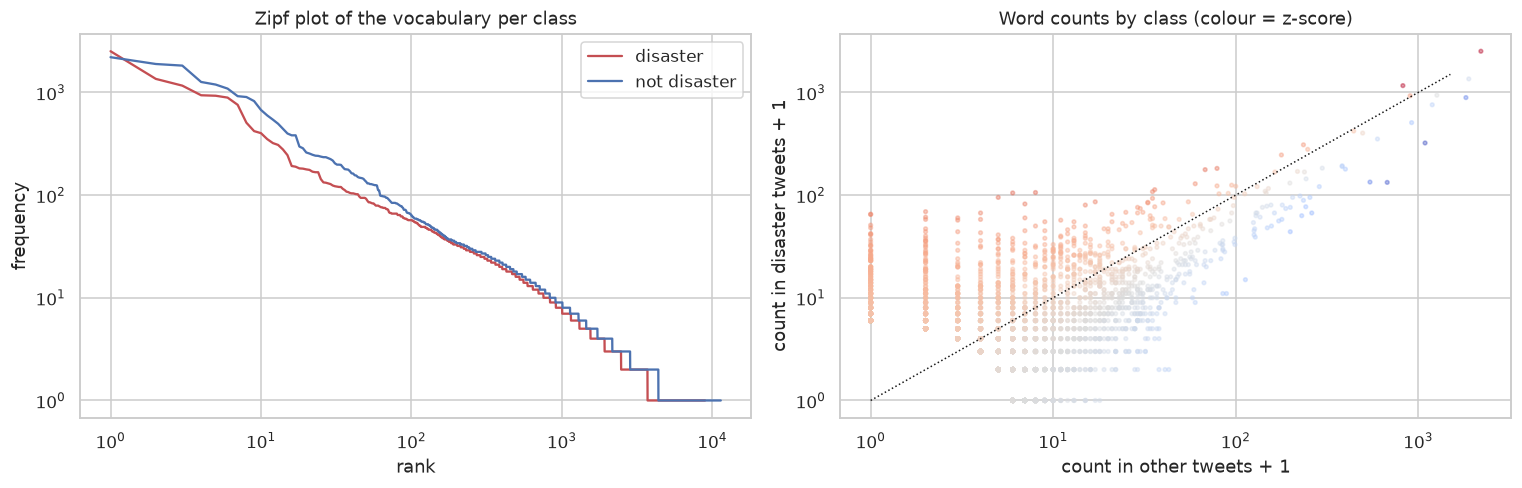

In [8]:
from nlp_common import norm
tok = norm(train.text).str.split()
c1 = Counter(w for ws in tok[y == 1] for w in ws); c0 = Counter(w for ws in tok[y == 0] for w in ws)
vocab = [w for w in set(c1) | set(c0) if c1[w] + c0[w] >= 5]; tot = {w: c1[w] + c0[w] for w in vocab}; T = sum(tot.values()); a0 = 0.1 * T
n1, n0 = sum(c1[w] for w in vocab), sum(c0[w] for w in vocab); z = {}
for w in vocab:
    aw = a0 * tot[w] / T
    d = np.log((c1[w] + aw) / (n1 + a0 - c1[w] - aw)) - np.log((c0[w] + aw) / (n0 + a0 - c0[w] - aw))
    z[w] = d / np.sqrt(1 / (c1[w] + aw) + 1 / (c0[w] + aw))
z = pd.Series(z).sort_values()
def bigrams(ws): return [" ".join(p) for p in zip(ws, ws[1:])]
b1 = Counter(g for ws in tok[y == 1] for g in bigrams(ws)); b0 = Counter(g for ws in tok[y == 0] for g in bigrams(ws))
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
z.tail(20).plot.barh(ax=axes[0, 0], color=PAL[1]); axes[0, 0].set_title("Words signalling a real disaster (z)")
z.head(20)[::-1].plot.barh(ax=axes[0, 1], color=PAL[0]); axes[0, 1].set_title("Words signalling figurative use (z)")
pd.Series(dict(b1.most_common(15)))[::-1].plot.barh(ax=axes[1, 0], color=PAL[1]); axes[1, 0].set_title("Most frequent bigrams: disaster tweets")
pd.Series(dict(b0.most_common(15)))[::-1].plot.barh(ax=axes[1, 1], color=PAL[0]); axes[1, 1].set_title("Most frequent bigrams: other tweets")
plt.tight_layout(); plt.savefig("assets/eda_07_discriminative_words.png", bbox_inches="tight"); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for cls, ctr, col in [(1, c1, PAL[1]), (0, c0, PAL[0])]:
    f = np.array(sorted(ctr.values(), reverse=True)); axes[0].loglog(np.arange(1, len(f) + 1), f, color=col, label=["not disaster", "disaster"][cls])
axes[0].set_xlabel("rank"); axes[0].set_ylabel("frequency"); axes[0].set_title("Zipf plot of the vocabulary per class"); axes[0].legend()
vs = pd.DataFrame({"disaster": [c1[w] for w in vocab], "other": [c0[w] for w in vocab]}, index=vocab)
axes[1].scatter(vs["other"] + 1, vs["disaster"] + 1, s=6, alpha=.4, c=z.reindex(vocab), cmap="coolwarm"); axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].plot([1, 1500], [1, 1500], "k:", lw=1); axes[1].set_xlabel("count in other tweets + 1"); axes[1].set_ylabel("count in disaster tweets + 1"); axes[1].set_title("Word counts by class (colour = z-score)")
plt.tight_layout(); plt.savefig("assets/eda_08_zipf_word_scatter.png", bbox_inches="tight"); plt.show()

## 7. Does the test set look like the training set? Adversarial validation

A classifier is trained to tell training tweets from test tweets. An out-of-fold AUC near 0.5 means the two sets are
exchangeable, so cross-validation on training data is a fair estimate of test performance.

train-vs-test adversarial AUC: 0.4863


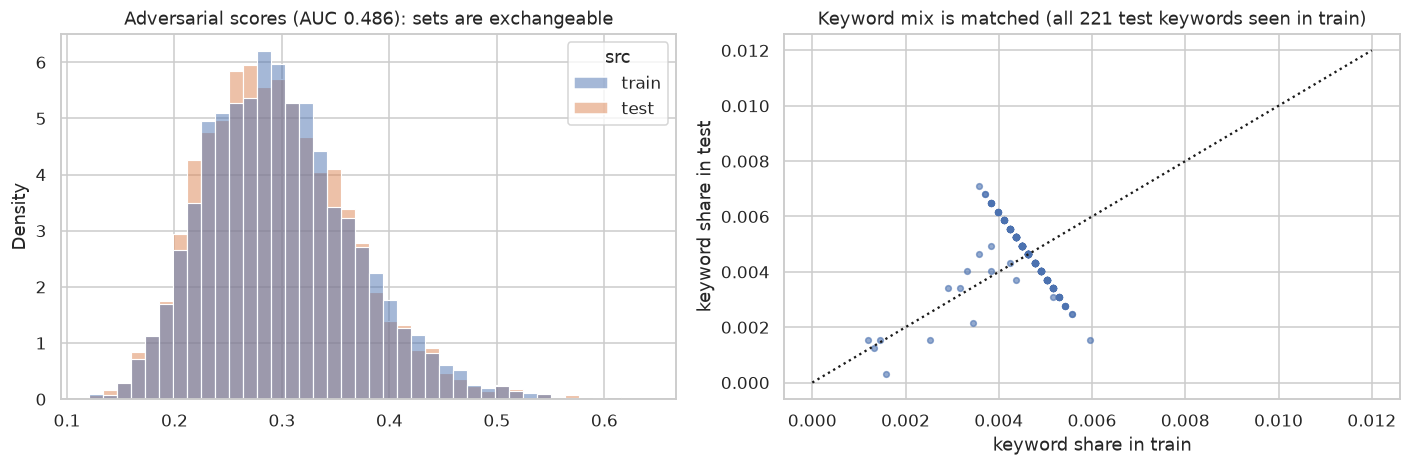

In [9]:
both = pd.concat([train.assign(src=0), test.assign(src=1)], ignore_index=True)
X_av = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit_transform(norm(both.text))
lr_av = LogisticRegression(C=1.0, max_iter=500, solver="liblinear")
p_av = cross_val_predict(lr_av, X_av, both.src, cv=StratifiedKFold(5, shuffle=True, random_state=42), method="predict_proba")[:, 1]
auc_av = roc_auc_score(both.src, p_av); print(f"train-vs-test adversarial AUC: {auc_av:.4f}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
sns.histplot(x=p_av, hue=both.src.map({0: "train", 1: "test"}), bins=40, stat="density", common_norm=False, ax=axes[0]); axes[0].set_title(f"Adversarial scores (AUC {auc_av:.3f}): sets are exchangeable")
kd = pd.DataFrame({"train": train.keyword.value_counts(normalize=True), "test": test.keyword.value_counts(normalize=True)}).fillna(0)
axes[1].scatter(kd["train"], kd["test"], s=14, alpha=.6); axes[1].plot([0, .012], [0, .012], "k:"); axes[1].set_xlabel("keyword share in train"); axes[1].set_ylabel("keyword share in test")
axes[1].set_title(f"Keyword mix is matched (all {int(test.keyword.dropna().isin(train.keyword).all())*len(kd)} test keywords seen in train)")
plt.tight_layout(); plt.savefig("assets/eda_09_train_test_shift.png", bbox_inches="tight"); plt.show()
json.dump(dict(adversarial_auc=auc_av), open("results/adversarial_validation.json", "w"))

## 8. Geometry of the data: a 2-D projection of TF-IDF space

Truncated SVD (latent semantic analysis) of word TF-IDF, then the first two components, coloured by label and by the
top keyword groups. Overlap between the classes in 2-D shows why a linear model on words has a ceiling and why context
(a transformer) should help.

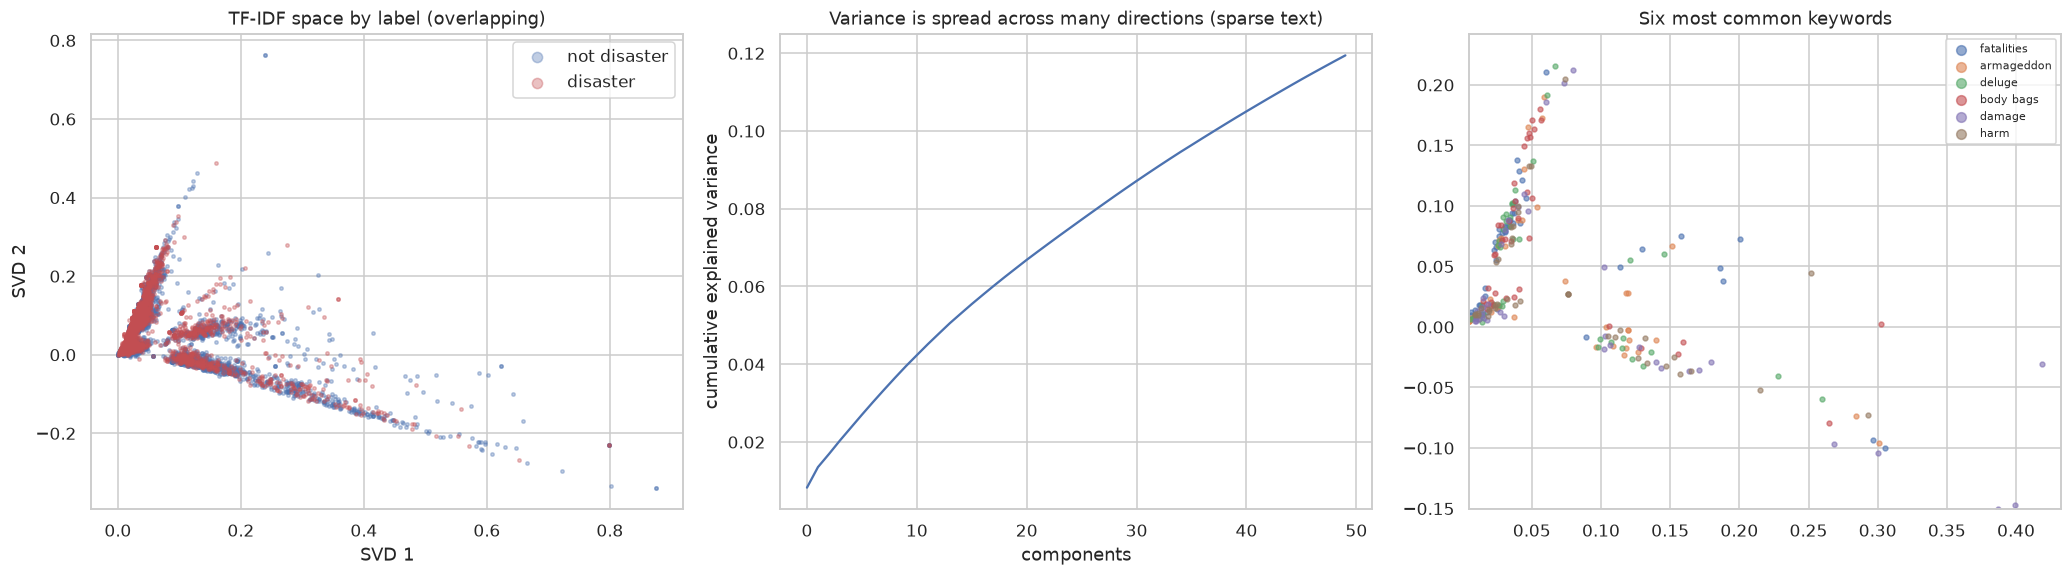

AUC of a linear model on the 50-d SVD projection (out-of-fold): 0.7861


In [10]:
Xw = TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True, stop_words="english").fit_transform(norm(train.text))
svd = TruncatedSVD(50, random_state=42); Z = svd.fit_transform(Xw)
fig, axes = plt.subplots(1, 3, figsize=(19, 5.4))
for cls in (0, 1): axes[0].scatter(Z[y == cls, 0], Z[y == cls, 1], s=5, alpha=.35, color=PAL[cls], label=["not disaster", "disaster"][cls])
axes[0].set_xlabel("SVD 1"); axes[0].set_ylabel("SVD 2"); axes[0].set_title("TF-IDF space by label (overlapping)"); axes[0].legend(markerscale=3)
axes[1].plot(np.cumsum(svd.explained_variance_ratio_)); axes[1].set_xlabel("components"); axes[1].set_ylabel("cumulative explained variance"); axes[1].set_title("Variance is spread across many directions (sparse text)")
topkw = train.keyword.value_counts().index[:6]
for k in topkw:
    mk = (train.keyword == k).values; axes[2].scatter(Z[mk, 0], Z[mk, 1], s=10, alpha=.6, label=k.replace("%20", " "))
axes[2].set_title("Six most common keywords"); axes[2].legend(fontsize=7, markerscale=2); axes[2].set_xlim(np.percentile(Z[:, 0], [1, 99])); axes[2].set_ylim(np.percentile(Z[:, 1], [1, 99]))
plt.tight_layout(); plt.savefig("assets/eda_10_tfidf_svd_projection.png", bbox_inches="tight"); plt.show()
# how separable is the label inside the 50-d projection? (linear, out-of-fold)
p50 = cross_val_predict(LogisticRegression(max_iter=500), Z, y, cv=StratifiedKFold(5, shuffle=True, random_state=42), method="predict_proba")[:, 1]
print(f"AUC of a linear model on the 50-d SVD projection (out-of-fold): {roc_auc_score(y, p50):.4f}")